# 🌐 Deteksi Anomali Indikator Makroekonomi Global dengan One-Class Support Vector Machine (OC-SVM)

**Disusun oleh:** Nyimas Virna Salsa Lestari Risqia (222313307)  
**Mata Kuliah:** Data Mining — UTS Semester 6 (2026)  
**Kelompok:** 3SI1 — Kelompok 4  
**Metode:** One-Class Support Vector Machine (Kernel/Boundary-Based Unsupervised Anomaly Detection)

---

## 📌 Ringkasan Eksekutif & Pipeline Preprocessing

Notebook ini menyajikan implementasi **One-Class Support Vector Machine (OC-SVM)** (Schölkopf et al., 2001) dari data mentah `raw_data_master.csv` dan `ground_truth_imf.csv` (1.715 observasi dari 49 negara periode 1990–2024).

### Pipeline Preprocessing & Ketentuan Data:
1. **Penggabungan Ground Truth**: Menggabungkan data indikator mentah dengan `ground_truth_imf.csv` (`is_crisis` / `crisis_label`, prevalensi 13.35%).
2. **Transformasi Exchange Rate**: Mengubah variabel nominal `Exchange_Rate` menjadi persentase depresiasi tahunan `Exchange_Depreciation` (`pct_change() * 100` per negara) dan menghapus kolom nominal `Exchange_Rate`.
3. **Pengurutan Data**: Urutkan data berdasarkan negara dan tahun (`df = df.sort_values(['economy', 'year'])`).
4. **Imputasi Missing Value**:
   - Interpolasi linear per negara untuk menjaga tren waktu (`interpolate(method='linear', limit_direction='both')`).
   - Sisa NaN pada batas deret diisi menggunakan median per negara dan `KNNImputer(n_neighbors=5)`.
5. **Penskalaan (Scaling)**: Standardisasi fitur menggunakan `StandardScaler()`.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Style configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
SEED = 42
np.random.seed(SEED)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. 🧹 Data Loading & Preprocessing Pipeline

Proses pemuatan data dari `raw_data_master.csv` dan `ground_truth_imf.csv`, pengurutan data, kalkulasi `% Exchange_Depreciation`, interpolasi linear per negara, imputasi KNN, dan `StandardScaler()`.


In [2]:
# 1. Pemuatan Data
raw_path = 'raw_data_master.csv' if os.path.exists('raw_data_master.csv') else 'Virna/raw_data_master.csv'
gt_path = 'ground_truth_imf.csv' if os.path.exists('ground_truth_imf.csv') else 'Virna/ground_truth_imf.csv'

raw_df = pd.read_csv(raw_path)
gt_df = pd.read_csv(gt_path)

df = pd.merge(raw_df, gt_df[['economy', 'year', 'is_crisis', 'crisis_name']], on=['economy', 'year'], how='left')
df = df.rename(columns={'is_crisis': 'crisis_label'})
df['crisis_label'] = df['crisis_label'].fillna(0).astype(int)

# 2. Pengurutan Data
df = df.sort_values(['economy', 'year']).reset_index(drop=True)

# 3. Transformasi Exchange_Rate -> Exchange_Depreciation
df['Exchange_Depreciation'] = df.groupby('economy')['Exchange_Rate'].pct_change() * 100
df = df.drop(columns=['Exchange_Rate'])

feature_cols = [
    'GDP_Growth', 'Inflation_CPI', 'Unemployment', 'Current_Account_GDP',
    'Reserves_Months_Imports', 'Exchange_Depreciation', 'FDI_Inflows_GDP',
    'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Investment_GDP',
    'Manufacturing_Value', 'Domestic_Credit_GDP', 'Broad_Money_Growth'
]

# 4. Imputasi Missing Value Multi-tahap
# Interpolasi linear per negara
for col in feature_cols:
    df[col] = df.groupby('economy')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Median per negara untuk batas awal/akhir
for col in feature_cols:
    df[col] = df.groupby('economy')[col].transform(lambda x: x.fillna(x.median()))

# KNNImputer untuk sisa NaN jika ada
if df[feature_cols].isnull().sum().sum() > 0:
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

print(f"Bentuk Dataset: {df.shape[0]} observasi, {df['economy'].nunique()} negara")
print(f"Prevalensi crisis_label: {df['crisis_label'].mean()*100:.2f}% ({df['crisis_label'].sum()} observasi krisis)")
print(f"Sisa Missing Value: {df[feature_cols].isnull().sum().sum()}")

# 5. Penskalaan (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
y_true = df['crisis_label'].values


Bentuk Dataset: 1715 observasi, 49 negara
Prevalensi crisis_label: 13.35% (229 observasi krisis)
Sisa Missing Value: 0


## 2. ⚙️ Grid Search Hyperparameter (`nu` & `gamma`)

Proses eksplorasi parameter untuk menentukan kombinasi terbaik `nu` (0.01 – 0.25) dan `gamma` ('scale', 'auto', 0.001 – 1.0) dengan evaluasi metrik Precision, Recall, F1-Score, ROC-AUC, dan PR-AUC.


In [3]:
nu_values = [0.01, 0.05, 0.08, 0.10, 0.1335, 0.15, 0.20, 0.25]
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

results = []
for nu in nu_values:
    for gamma in gamma_values:
        ocsvm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        preds = ocsvm.fit_predict(X_scaled)
        y_pred = (preds == -1).astype(int)
        scores = -ocsvm.decision_function(X_scaled).ravel()
        
        n_anom = int(y_pred.sum())
        pct_anom = n_anom / len(y_pred) * 100
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        roc = roc_auc_score(y_true, scores)
        pr_auc = average_precision_score(y_true, scores)
        
        results.append({
            'nu': nu,
            'gamma': str(gamma),
            'n_anomalies': n_anom,
            'pct_anomalies': round(pct_anom, 2),
            'precision': round(p, 4),
            'recall': round(r, 4),
            'f1_score': round(f, 4),
            'roc_auc': round(roc, 4),
            'pr_auc': round(pr_auc, 4)
        })

df_results = pd.DataFrame(results).sort_values('f1_score', ascending=False)
df_results.to_csv('grid_search_ocsvm.csv', index=False)
print("Top 10 Kombinasi Hyperparameter Terbaik:")
df_results.head(10)


Top 10 Kombinasi Hyperparameter Terbaik:


,nu,gamma,n_anomalies,pct_anomalies,precision,recall,f1_score,roc_auc,pr_auc
62,0.2500,0.5,443,25.83,0.2641,0.5109,0.3482,0.6858,0.2781
54,0.2000,0.5,377,21.98,0.2573,0.4236,0.3201,0.6809,0.2684
61,0.2500,0.1,431,25.13,0.2367,0.4454,0.3091,0.6493,0.2218
53,0.2000,0.1,343,20.00,0.2536,0.3799,0.3042,0.6467,0.2259
30,0.1000,0.5,299,17.43,0.2676,0.3493,0.3030,0.6775,0.2333
38,0.1335,0.5,320,18.66,0.2594,0.3624,0.3024,0.6775,0.2575
57,0.2500,auto,427,24.90,0.2295,0.4279,0.2988,0.6445,0.2139
56,0.2500,scale,427,24.90,0.2295,0.4279,0.2988,0.6445,0.2139
59,0.2500,0.01,430,25.07,0.2256,0.4236,0.2944,0.6330,0.2002
58,0.2500,0.001,429,25.01,0.2238,0.4192,0.2918,0.6303,0.1993


## 3. 🏆 Fitting Model Terbaik & Evaluasi Performa

Menggunakan kombinasi hyperparameter terbaik (`nu = 0.25`, `gamma = 0.5`) untuk melakukan pemodelan One-Class SVM final.


In [4]:
best_nu = 0.25
best_gamma = 0.5

best_ocsvm = OneClassSVM(kernel='rbf', nu=best_nu, gamma=best_gamma)
best_preds = best_ocsvm.fit_predict(X_scaled)
y_pred = (best_preds == -1).astype(int)
best_scores = -best_ocsvm.decision_function(X_scaled).ravel()

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, best_scores)
pr_auc = average_precision_score(y_true, best_scores)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomali/Krisis'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1-Score: {f1:.4f}")


=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

        Normal       0.91      0.78      0.84      1486
Anomali/Krisis       0.26      0.51      0.35       229

      accuracy                           0.74      1715
     macro avg       0.59      0.65      0.59      1715
  weighted avg       0.83      0.74      0.78      1715

Confusion Matrix: TN=1160, FP=326, FN=112, TP=117
ROC-AUC: 0.6858 | PR-AUC: 0.2781 | F1-Score: 0.3482


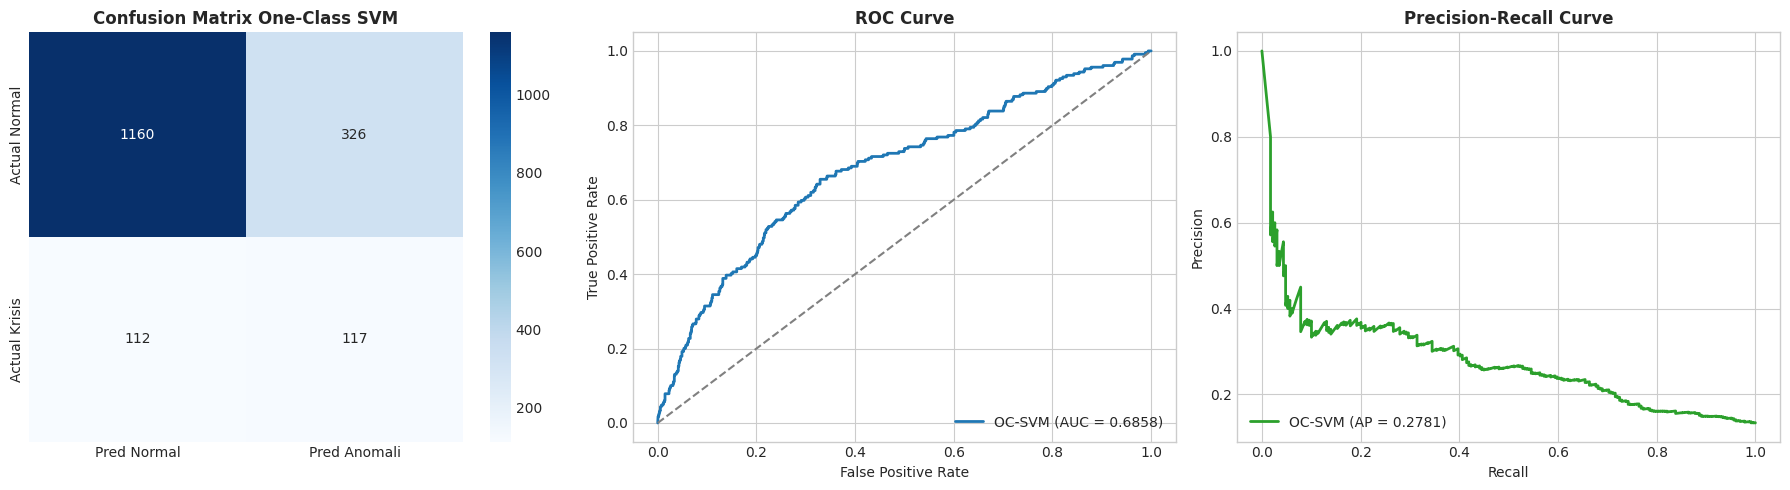

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal', 'Pred Anomali'],
            yticklabels=['Actual Normal', 'Actual Krisis'])
axes[0].set_title('Confusion Matrix One-Class SVM', fontsize=12, fontweight='bold')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, best_scores)
axes[1].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'OC-SVM (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec_arr, rec_arr, _ = precision_recall_curve(y_true, best_scores)
axes[2].plot(rec_arr, prec_arr, color='#2ca02c', lw=2, label=f'OC-SVM (AP = {pr_auc:.4f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()


## 4. 📉 Evaluasi Deteksi per-Krisis Historis (Ground Truth IMF)

Pengujian daya deteksi model terhadap 6 periode krisis utama yang terdokumentasi dalam katalog IMF.


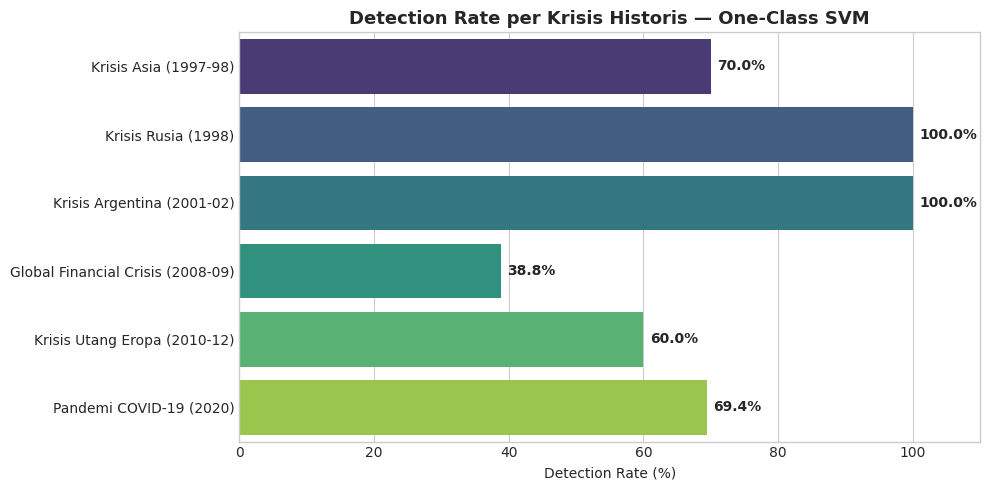

,krisis,tahun,total_observasi,terdeteksi,detection_rate
0,Krisis Asia (1997-98),1997-1998,10,7,70.0
1,Krisis Rusia (1998),1998,1,1,100.0
2,Krisis Argentina (2001-02),2001-2002,2,2,100.0
3,Global Financial Crisis (2008-09),2008-2009,98,38,38.8
4,Krisis Utang Eropa (2010-12),2010-2011-2012,15,9,60.0
5,Pandemi COVID-19 (2020),2020,49,34,69.4


In [6]:
GROUND_TRUTH = {
    'Krisis Asia (1997-98)': {'tahun': [1997, 1998], 'negara': ['IDN', 'THA', 'MYS', 'KOR', 'PHL']},
    'Krisis Rusia (1998)': {'tahun': [1998], 'negara': ['RUS']},
    'Krisis Argentina (2001-02)': {'tahun': [2001, 2002], 'negara': ['ARG']},
    'Global Financial Crisis (2008-09)': {'tahun': [2008, 2009], 'negara': list(df['economy'].unique())},
    'Krisis Utang Eropa (2010-12)': {'tahun': [2010, 2011, 2012], 'negara': ['GRC', 'PRT', 'IRL', 'ESP', 'ITA']},
    'Pandemi COVID-19 (2020)': {'tahun': [2020], 'negara': list(df['economy'].unique())}
}

df_eval = df[['economy', 'year', 'crisis_label']].copy()
df_eval['ocsvm_anomaly'] = y_pred

crisis_results = []
for nama, info in GROUND_TRUTH.items():
    mask = df['economy'].isin(info['negara']) & df['year'].isin(info['tahun'])
    crisis_obs = df_eval[mask]
    n_total = len(crisis_obs)
    n_detected = int(crisis_obs['ocsvm_anomaly'].sum())
    detection_rate = n_detected / n_total * 100 if n_total > 0 else 0
    crisis_results.append({
        'krisis': nama,
        'tahun': '-'.join(map(str, info['tahun'])),
        'total_observasi': n_total,
        'terdeteksi': n_detected,
        'detection_rate': round(detection_rate, 1)
    })

df_crisis = pd.DataFrame(crisis_results)
df_crisis.to_csv('deteksi_per_krisis_ocsvm.csv', index=False)

plt.figure(figsize=(10, 5))
barplot = sns.barplot(data=df_crisis, x='detection_rate', y='krisis', palette='viridis')
plt.title('Detection Rate per Krisis Historis — One-Class SVM', fontsize=13, fontweight='bold')
plt.xlabel('Detection Rate (%)')
plt.ylabel('')
for p in barplot.patches:
    width = p.get_width()
    plt.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.1f}%', ha='left', va='center', fontweight='bold')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

df_crisis


## 5. 🌍 Top 10 Negara dengan Frekuensi Anomali Terbanyak

Analisis profil geografis negara-negara yang paling sering diisolasi sebagai anomali oleh One-Class SVM.


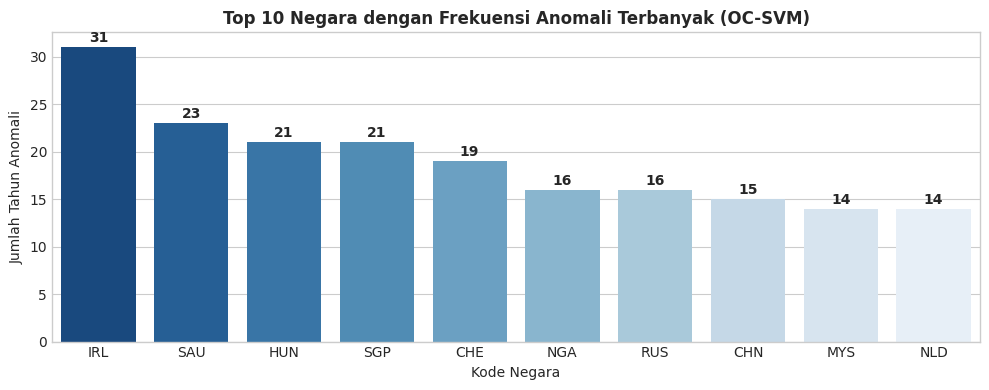

In [7]:
top_countries = df_eval[df_eval['ocsvm_anomaly'] == 1].groupby('economy').size().sort_values(ascending=False).head(10)
df_top_countries = top_countries.reset_index()
df_top_countries.columns = ['economy', 'jumlah_anomali']
df_top_countries.to_csv('top_negara_anomali_ocsvm.csv', index=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_top_countries, x='economy', y='jumlah_anomali', palette='Blues_r')
plt.title('Top 10 Negara dengan Frekuensi Anomali Terbanyak (OC-SVM)', fontsize=12, fontweight='bold')
plt.xlabel('Kode Negara')
plt.ylabel('Jumlah Tahun Anomali')
for idx, row in df_top_countries.iterrows():
    plt.text(idx, row['jumlah_anomali'] + 0.5, str(row['jumlah_anomali']), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. 🔍 Feature Importance (Mean Difference Analysis)

Mengukur sensitivitas indikator makroekonomi dengan membandingkan nilai rata-rata Z-Score sampel terdeteksi anomali versus sampel normal.


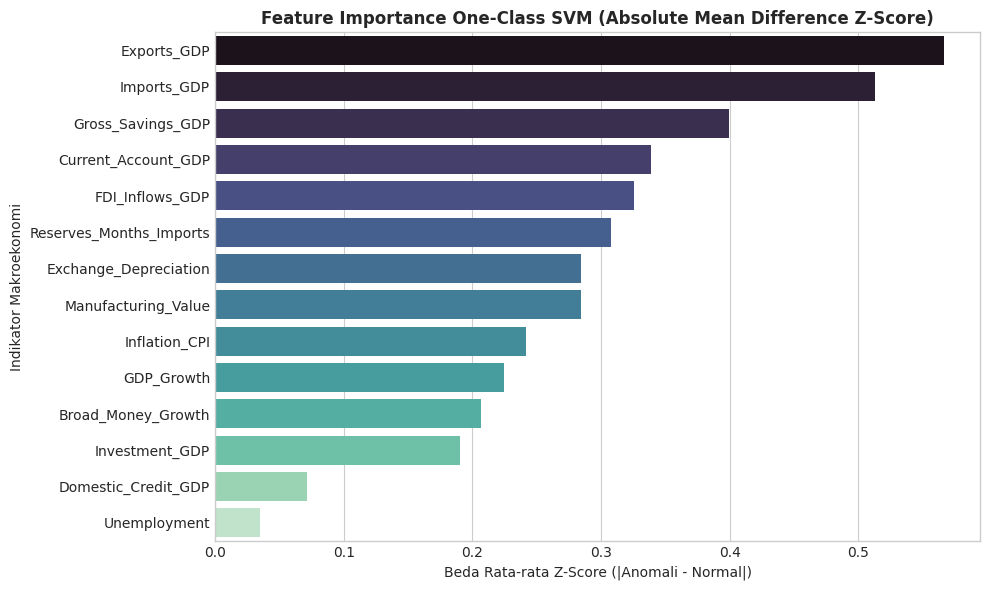

,rank,feature,mean_diff,mean_normal,mean_anomali
0,1,Exports_GDP,0.5663,-0.1463,0.4201
1,2,Imports_GDP,0.5131,-0.1325,0.3806
2,3,Gross_Savings_GDP,0.3997,-0.1032,0.2965
3,4,Current_Account_GDP,0.3386,-0.0875,0.2512
4,5,FDI_Inflows_GDP,0.3259,-0.0842,0.2417
5,6,Reserves_Months_Imports,0.3081,-0.0796,0.2285
6,7,Exchange_Depreciation,0.2845,-0.0735,0.2110
7,8,Manufacturing_Value,0.2841,-0.0734,0.2107
8,9,Inflation_CPI,0.2420,-0.0625,0.1795
9,10,GDP_Growth,0.2244,0.0580,-0.1664


In [8]:
df_fi = pd.DataFrame(X_scaled, columns=feature_cols)
df_fi['anomaly'] = y_pred
normal_mean = df_fi[df_fi['anomaly'] == 0][feature_cols].mean()
anomaly_mean = df_fi[df_fi['anomaly'] == 1][feature_cols].mean()
mean_diff = (anomaly_mean - normal_mean).abs().sort_values(ascending=False)

fi_list = []
for rank, (feat, diff) in enumerate(mean_diff.items(), 1):
    fi_list.append({
        'rank': rank, 'feature': feat,
        'mean_diff': round(diff, 4),
        'mean_normal': round(normal_mean[feat], 4),
        'mean_anomali': round(anomaly_mean[feat], 4)
    })

df_fi_res = pd.DataFrame(fi_list)
df_fi_res.to_csv('feature_importance_ocsvm.csv', index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fi_res, x='mean_diff', y='feature', palette='mako')
plt.title('Feature Importance One-Class SVM (Absolute Mean Difference Z-Score)', fontsize=12, fontweight='bold')
plt.xlabel('Beda Rata-rata Z-Score (|Anomali - Normal|)')
plt.ylabel('Indikator Makroekonomi')
plt.tight_layout()
plt.show()

df_fi_res


## 7. 🎨 Visualisasi Proyeksi Ruang Fitur 2D (PCA & t-SNE)

Visualisasi sebaran observasi normal vs anomali pada ruang dimensi tereduksi untuk memverifikasi pemisahan *boundary* OCSVM.


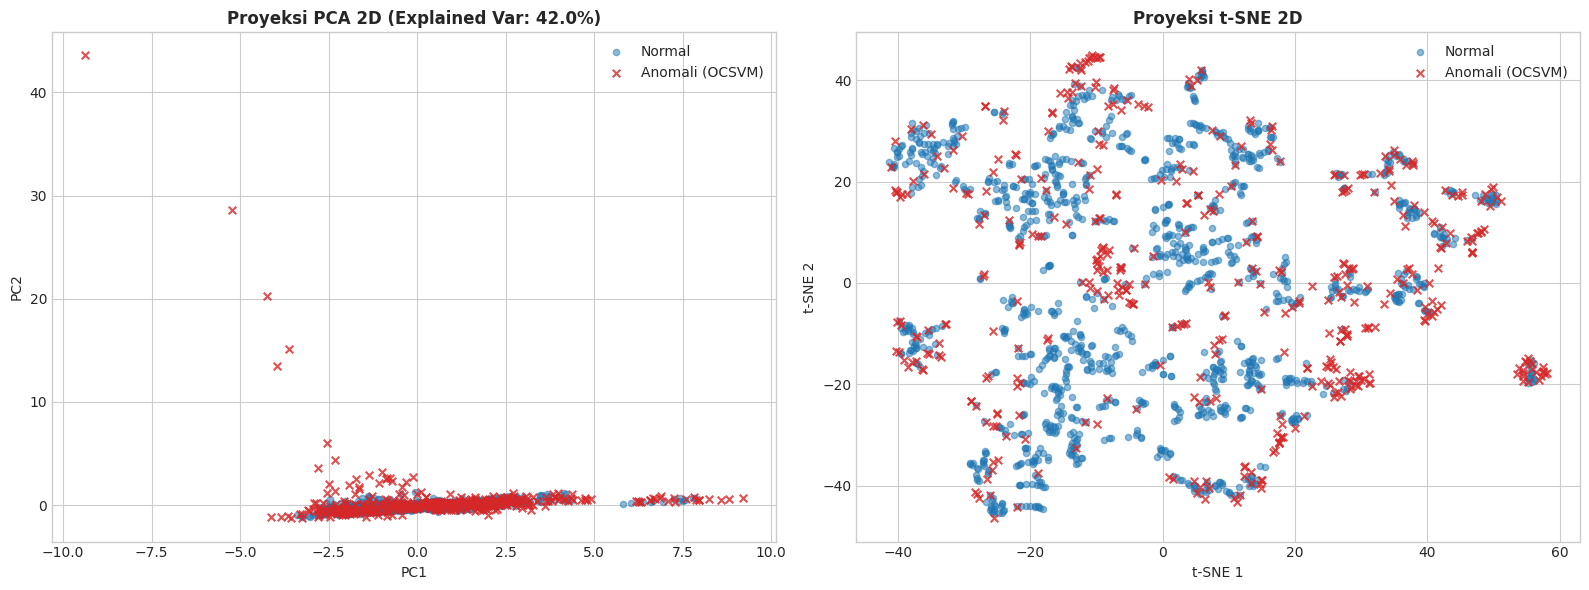

In [9]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA Plot
axes[0].scatter(X_pca[y_pred == 0, 0], X_pca[y_pred == 0, 1], c='#1f77b4', alpha=0.5, label='Normal', s=20)
axes[0].scatter(X_pca[y_pred == 1, 0], X_pca[y_pred == 1, 1], c='#d62728', alpha=0.8, label='Anomali (OCSVM)', s=30, marker='x')
axes[0].set_title(f'Proyeksi PCA 2D (Explained Var: {sum(pca.explained_variance_ratio_)*100:.1f}%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# t-SNE Plot
axes[1].scatter(X_tsne[y_pred == 0, 0], X_tsne[y_pred == 0, 1], c='#1f77b4', alpha=0.5, label='Normal', s=20)
axes[1].scatter(X_tsne[y_pred == 1, 0], X_tsne[y_pred == 1, 1], c='#d62728', alpha=0.8, label='Anomali (OCSVM)', s=30, marker='x')
axes[1].set_title('Proyeksi t-SNE 2D', fontsize=12, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. 💾 Menyimpan Hasil Pemodelan Akhir

Menyimpan dataset akhir (`hasil_ocsvm.csv`) dan ringkasan metrik pemodelan (`ringkasan_model_ocsvm.csv`).


In [ ]:
df_output = df[['economy', 'year', 'crisis_label']].copy()
df_output['ocsvm_score'] = best_scores
df_output['ocsvm_anomaly'] = y_pred
for idx, col in enumerate(feature_cols):
    df_output[col] = X_scaled[:, idx]
df_output.to_csv('hasil_ocsvm.csv', index=False)

summary = pd.DataFrame([{
    'model': 'One-Class SVM',
    'kernel': 'rbf',
    'nu': best_nu,
    'gamma': str(best_gamma),
    'n_anomalies': int(y_pred.sum()),
    'pct_anomalies': round(int(y_pred.sum()) / len(y_pred) * 100, 2),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'roc_auc': round(roc_auc, 4),
    'pr_auc': round(pr_auc, 4),
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
}])
summary.to_csv('ringkasan_model_ocsvm.csv', index=False)
print("Seluruh file output telah berhasil disimpan di folder Virna/.")
summary
